## Notebook for explaining the simple equations predicting savings from flexible operations

Explanation is in the outline document. Here the functions can be defined and some useful plots can be made

In [28]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
# Define the savings function
def calculate_savings_weekly(power_capacity, plant_chars, electricity_rate):
    
    power_capacity = np.asarray(power_capacity, dtype=float)
    total_hrs = 168
    num_off_peak_hrs = total_hrs - electricity_rate['num_peak_hrs']
    water_vol_shift = plant_chars['SEC'] * power_capacity * electricity_rate['num_peak_hrs']
    energy_consumption_base = plant_chars['power_base'] * total_hrs
    energy_capacity = power_capacity * electricity_rate['num_peak_hrs']

    condition = water_vol_shift / (plant_chars['Q_perm_max'] - plant_chars['Q_perm_base']) < num_off_peak_hrs
    time_shift = np.where(
        condition,
        num_off_peak_hrs,
        power_capacity * num_off_peak_hrs / (plant_chars['SEC'] + plant_chars['Q_perm_min'])
    )
    
    off_peak_power_increase = energy_capacity / time_shift

    savings = power_capacity * electricity_rate['peak_demand_cost'] - off_peak_power_increase * electricity_rate['off_peak_demand_cost'] + energy_consumption_base * (electricity_rate['peak_consumption_cost'] - electricity_rate['off_peak_consumption_cost'])
    return savings

In [30]:
#Define a function giving range of power capacities achievable for varying the flowrate
def var_flow_power_cap_range(plant_chars):
    Q_perm_min = plant_chars['Q_min_brine'] * plant_chars['recovery'] / (1 - plant_chars['recovery'])
    power_capacity = Q_perm_min * plant_chars['SEC']
    return power_capacity

In [31]:
# Define a function for the additional brine costs associated with lower recovery rates
def additional_brine_costs(plant_chars):
    #TODO: Implement this if it seems relevant to include in the analysis
    return 0

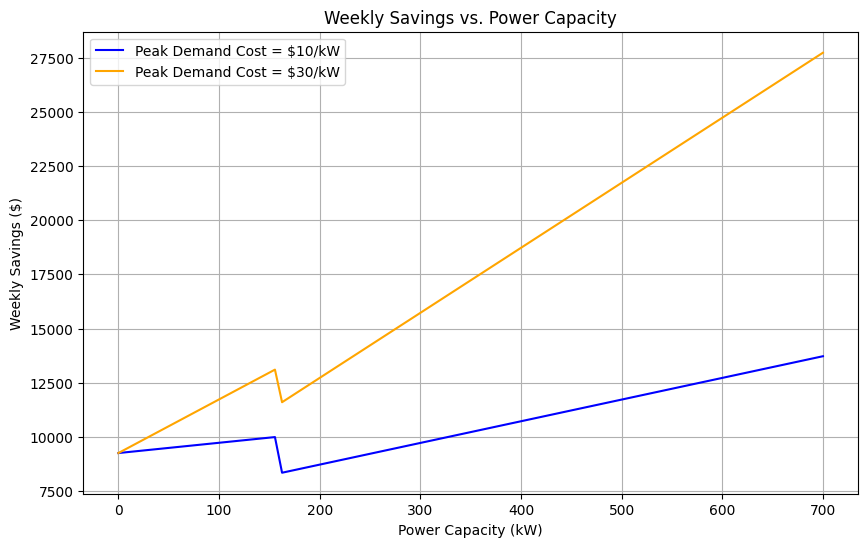

In [32]:
# Define the plant characteristics
wrd_plant_chars = {'SEC':0.44, 'Q_perm_min': 520 * 0.925, 'power_base': 1102, 'Q_perm_base': 605 * 0.925, 'Q_perm_max': 625 * 0.925, 'recovery': 0.925, 'Q_min_brine': 45}

# Plot the savings for two different peak demand costs
sample_week_1_rate = {'num_peak_hrs': 35, 'peak_demand_cost': 10, 'off_peak_demand_cost': 20, 'peak_consumption_cost': 0.15, 'off_peak_consumption_cost': 0.10}
sample_week_2_rate = {'num_peak_hrs': 35, 'peak_demand_cost': 30, 'off_peak_demand_cost': 20, 'peak_consumption_cost': 0.15, 'off_peak_consumption_cost': 0.10}

x = np.linspace(0, 700, 100)
y1 = calculate_savings_weekly(x, wrd_plant_chars, sample_week_1_rate)
y2 = calculate_savings_weekly(x, wrd_plant_chars, sample_week_2_rate)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='Peak Demand Cost = $10/kW', color='blue')
plt.plot(x, y2, label='Peak Demand Cost = $30/kW', color='orange')
plt.title('Weekly Savings vs. Power Capacity')
plt.xlabel('Power Capacity (kW)')
plt.ylabel('Weekly Savings ($)')
plt.legend()
plt.grid(True)
plt.show()

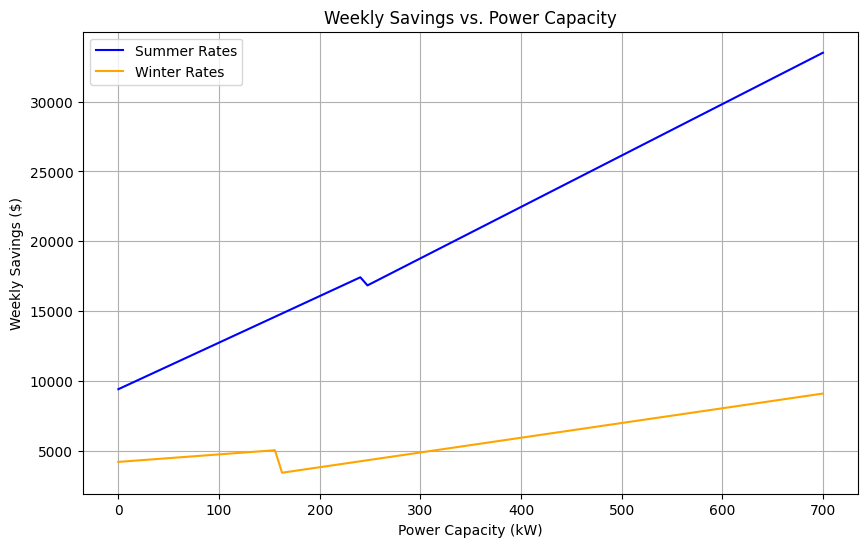

In [33]:
# Plot the savings for summer and winter rates
summer_weekly_rate = {'num_peak_hrs': 25, 'peak_demand_cost': 36.78, 'off_peak_demand_cost': 19.94, 'peak_consumption_cost': 0.1525, 'off_peak_consumption_cost': 0.1016}
winter_weekly_rate = {'num_peak_hrs': 35, 'peak_demand_cost': 10.54, 'off_peak_demand_cost': 19.64, 'peak_consumption_cost': 0.1157, 'off_peak_consumption_cost': 0.0929}

x = np.linspace(0, 700, 100)
y1 = calculate_savings_weekly(x, wrd_plant_chars, summer_weekly_rate)
y2 = calculate_savings_weekly(x, wrd_plant_chars, winter_weekly_rate)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='Summer Rates', color='blue')
plt.plot(x, y2, label='Winter Rates', color='orange')
plt.title('Weekly Savings vs. Power Capacity')
plt.xlabel('Power Capacity (kW)')
plt.ylabel('Weekly Savings ($)')
plt.legend()
plt.grid(True)
plt.show()